# Analisi ESG e Performance Finanziaria – Stellantis

## Obiettivo

Valutare la relazione tra sostenibilità (quota energia rinnovabile) e performance economica (ricavi e utile netto) nel periodo 2021–2025.

## Dataset

* ESG: Energy indicators (Excel – Stellantis)
* Financial: dati sintetici per analisi esplorativa

## Output

* Trend energetici
* Mix rinnovabile vs non rinnovabile
* Correlazioni ESG–Finance
* Insight strategici


In [61]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "data_raw"
PROCESSED_DIR = BASE_DIR / "data_processed"

In [62]:
file_esg = RAW_DIR / "ESG-Performance-Indicators.xlsx"
xls = pd.ExcelFile(file_esg)

In [63]:
df_env = pd.read_excel(file_esg, sheet_name="Environmental", header=1)

In [64]:
df_env = df_env.dropna(how="all")
df_env.head()

,Indicator,Unit,Target,2025,2024,2023,2022,2021,Notes on the data
1,Energy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total energy consumption related to own operat...,MWh,,12577752,12311232,14575126,15494891,16058210,Adjustments to the 2021 base year have been ma...
3,Total energy consumption from non-renewable so...,MWh,NaN,10644607,10389747,12708948,13770563,14871538,Adjustments to the 2021 base year have been ma...
4,Total energy consumption from nuclear sources,MWh,,1703205,1617055,1839044,1813354,1770296,Figures reported for 2021–2023 are not compara...
5,Total fossil energy consumption,MWh,NaN,8941402,8772692,10869904,11957209,13101242,2021-2023 total fossil energy consumption is e...


In [65]:
df_env = df_env.reset_index(drop=True)

In [66]:
df_env = df_env[df_env["Indicator"].notna()]
df_env.head()

,Indicator,Unit,Target,2025,2024,2023,2022,2021,Notes on the data
0,Energy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total energy consumption related to own operat...,MWh,,12577752,12311232,14575126,15494891,16058210,Adjustments to the 2021 base year have been ma...
2,Total energy consumption from non-renewable so...,MWh,NaN,10644607,10389747,12708948,13770563,14871538,Adjustments to the 2021 base year have been ma...
3,Total energy consumption from nuclear sources,MWh,,1703205,1617055,1839044,1813354,1770296,Figures reported for 2021–2023 are not compara...
4,Total fossil energy consumption,MWh,NaN,8941402,8772692,10869904,11957209,13101242,2021-2023 total fossil energy consumption is e...


In [67]:
years = [2025, 2024, 2023, 2022, 2021]

In [68]:
for col in years:
    df_env[col] = pd.to_numeric(df_env[col], errors="coerce")

In [69]:
df_env = df_env[df_env["Indicator"] != "Energy"]
df_env.head()

,Indicator,Unit,Target,2025,2024,2023,2022,2021,Notes on the data
1,Total energy consumption related to own operat...,MWh,,12577752.0,12311232.0,14575126.0,15494891.0,16058210.0,Adjustments to the 2021 base year have been ma...
2,Total energy consumption from non-renewable so...,MWh,NaN,10644607.0,10389747.0,12708948.0,13770563.0,14871538.0,Adjustments to the 2021 base year have been ma...
3,Total energy consumption from nuclear sources,MWh,,1703205.0,1617055.0,1839044.0,1813354.0,1770296.0,Figures reported for 2021–2023 are not compara...
4,Total fossil energy consumption,MWh,NaN,8941402.0,8772692.0,10869904.0,11957209.0,13101242.0,2021-2023 total fossil energy consumption is e...
5,Fuel consumption from coal and coal products,MWh,,68442.0,70138.0,81226.0,139833.0,145004.0,2021-2023 is combustible energy from Coke (fi...


In [70]:
output_path = PROCESSED_DIR / "environmental_clean.csv"

df_env.to_csv(output_path, index=False)

print("File salvato:", output_path)

File salvato: ..\data_processed\environmental_clean.csv


In [71]:
energy_total = df_env[
    df_env["Indicator"].str.contains("Total energy consumption related to own", case=False, na=False)
]

In [72]:
import matplotlib.pyplot as plt


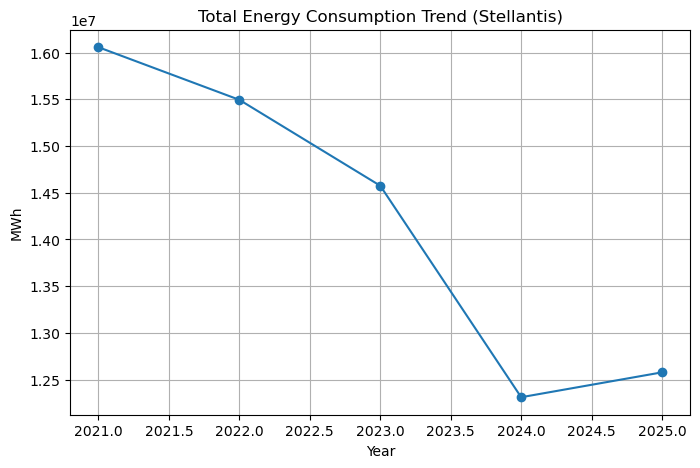

In [73]:
years = [2021, 2022, 2023, 2024, 2025]
values = energy_total[years].values.flatten()

plt.figure(figsize=(8,5))
plt.plot(years, values, marker='o')

plt.title("Total Energy Consumption Trend (Stellantis)")
plt.xlabel("Year")
plt.ylabel("MWh")
plt.grid()

plt.show()

Il consumo energetico totale di Stellantis mostra una riduzione significativa tra il 2021 e il 2024, suggerendo un miglioramento dell’efficienza operativa o una riduzione dell’attività produttiva. Nel 2025 si osserva una lieve ripresa, che potrebbe indicare un aumento della produzione o un cambiamento nelle strategie energetiche.”

In [74]:
renewable_total = df_env[
    df_env["Indicator"].str.contains("Total energy consumption from renewable sources", case=False, na=False)
]

non_renewable_total = df_env[
    df_env["Indicator"].str.contains("Total energy consumption from non-renewable sources", case=False, na=False)
]

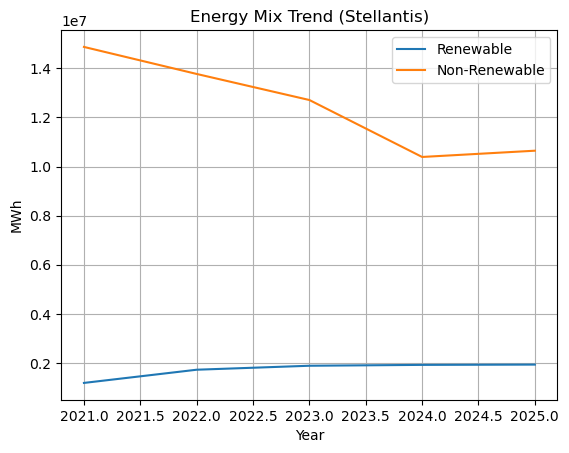

In [75]:
years = [2021, 2022, 2023, 2024, 2025]

renewable_values = renewable_total[years].values.flatten()
non_renewable_values = non_renewable_total[years].values.flatten()

plt.figure()

plt.plot(years, renewable_values, label="Renewable")
plt.plot(years, non_renewable_values, label="Non-Renewable")

plt.title("Energy Mix Trend (Stellantis)")
plt.xlabel("Year")
plt.ylabel("MWh")
plt.legend()
plt.grid()

plt.show()

“L’analisi del mix energetico evidenzia una riduzione significativa del consumo di energia da fonti non rinnovabili tra il 2021 e il 2024, accompagnata da un progressivo aumento dell’energia da fonti rinnovabili. Questo suggerisce un miglioramento nella strategia di sostenibilità energetica di Stellantis, anche se la dipendenza da fonti non rinnovabili rimane predominante.”

In [76]:
renewable_share = (renewable_values / (renewable_values + non_renewable_values)) * 100

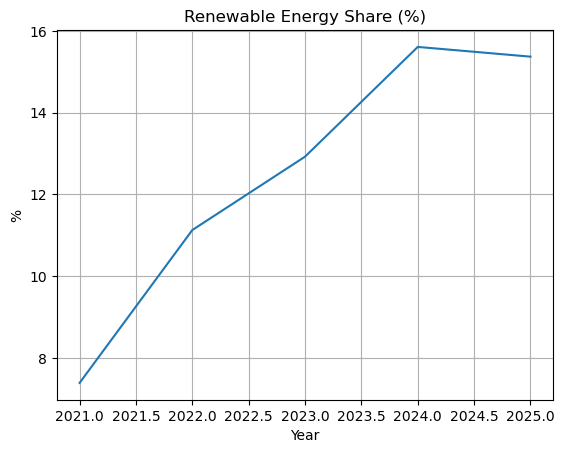

In [77]:
plt.figure()

plt.plot(years, renewable_share)
plt.title("Renewable Energy Share (%)")
plt.xlabel("Year")
plt.ylabel("%")
plt.grid()

plt.show()

“La quota di energia rinnovabile sul totale mostra una crescita significativa tra il 2021 e il 2024, passando da circa il 7% a oltre il 15%. Questo indica un miglioramento concreto nella strategia di sostenibilità energetica di Stellantis. Tuttavia, nel 2025 si osserva una leggera stabilizzazione, suggerendo un possibile rallentamento nel ritmo di transizione energetica.”

In [78]:
import pandas as pd

renewable_df = pd.DataFrame({
    "Year": years,
    "Renewable %": renewable_share
})

renewable_df["YoY Growth %"] = renewable_df["Renewable %"].pct_change() * 100

renewable_df

,Year,Renewable %,YoY Growth %
0,2021,7.389809,NaN
1,2022,11.128365,50.590693
2,2023,12.923342,16.129745
3,2024,15.607577,20.770442
4,2025,15.369559,-1.525016


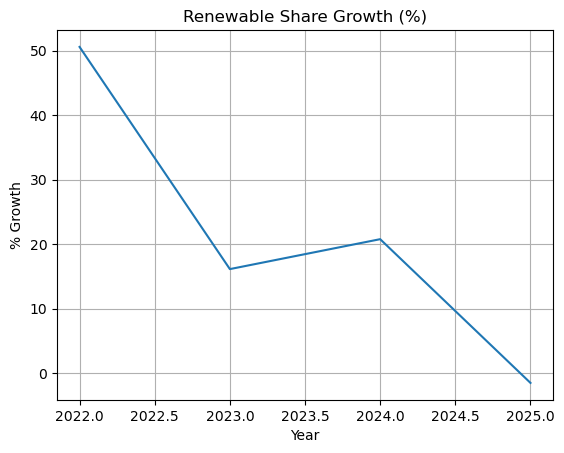

In [79]:
plt.figure()

plt.plot(
    renewable_df["Year"][1:], 
    renewable_df["YoY Growth %"][1:]
)

plt.title("Renewable Share Growth (%)")
plt.xlabel("Year")
plt.ylabel("% Growth")
plt.grid()

plt.show()

“La crescita anno su anno della quota di energia rinnovabile mostra un forte incremento iniziale nel 2022 (+50%), seguito da un rallentamento negli anni successivi. Nel 2025 si osserva una lieve contrazione (-1.5%), suggerendo una possibile saturazione o difficoltà nel mantenere lo stesso ritmo di crescita della transizione energetica.”

In [80]:
renewable_df.describe()

,Year,Renewable %,YoY Growth %
count,5.000000,5.000000,4.000000
mean,2023.000000,12.483730,21.491466
std,1.581139,3.393550,21.647104
min,2021.000000,7.389809,-1.525016
25%,2022.000000,11.128365,11.716055
50%,2023.000000,12.923342,18.450093
75%,2024.000000,15.369559,28.225505
max,2025.000000,15.607577,50.590693


L’analisi ha evidenziato una riduzione significativa del consumo energetico totale tra il 2021 e il 2024, seguita da una lieve ripresa nel 2025. Parallelamente, si osserva una diminuzione dell’utilizzo di fonti non rinnovabili e un aumento progressivo dell’energia rinnovabile.

La quota di energia rinnovabile è più che raddoppiata nel periodo analizzato, passando da circa il 7% a oltre il 15%. Tuttavia, la crescita anno su anno mostra un rallentamento dopo un forte incremento iniziale, fino a una lieve contrazione nel 2025.

Questo suggerisce che la transizione energetica, inizialmente rapida, entra in una fase di maturità in cui ulteriori miglioramenti richiedono interventi strutturali più complessi.


Il progetto dimostra la capacità di trasformare dati ESG grezzi in insight utili tramite data cleaning, costruzione di KPI e analisi temporale.

In [81]:
df_env = df_env.dropna(how="all")
df_env = df_env[df_env["Indicator"].notna()]
df_env = df_env[df_env["Indicator"] != "Energy"]
df_env = df_env.reset_index(drop=True)

In [82]:
years = [2021, 2022, 2023, 2024, 2025]

for col in years:
    df_env[col] = pd.to_numeric(df_env[col], errors="coerce")

In [83]:
energy_total = df_env[
    df_env["Indicator"].str.contains("Total energy consumption related to own operations", case=False, na=False)
]

renewable = df_env[
    df_env["Indicator"].str.contains("renewable", case=False, na=False)
]

non_renewable = df_env[
    df_env["Indicator"].str.contains("non-renewable", case=False, na=False)
]

energy_total

,Indicator,Unit,Target,2025,2024,2023,2022,2021,Notes on the data
0,Total energy consumption related to own operat...,MWh,,12577752.0,12311232.0,14575126.0,15494891.0,16058210.0,Adjustments to the 2021 base year have been ma...


In [84]:
renewable_total = renewable[
    renewable["Indicator"].str.contains("Total energy consumption from renewable sources", case=False, na=False)
]

non_renewable_total = non_renewable[
    non_renewable["Indicator"].str.contains("Total energy consumption from non-renewable sources", case=False, na=False)
]

In [85]:
renewable_values = renewable_total[years].values.flatten()
non_renewable_values = non_renewable_total[years].values.flatten()

renewable_share = (renewable_values / (renewable_values + non_renewable_values)) * 100

In [86]:
# Arrotondiamo i valori (IMPORTANTE)
renewable_share = renewable_share.round(2)

esg_data = pd.DataFrame({
    "Year": years,
    "Renewable_%": renewable_share
})


In [87]:
financial_data = pd.DataFrame({
    "Year": [2021, 2022, 2023, 2024, 2025],
    "Revenue": [152000, 179000, 189000, 173000, 180000],
    "Net_Income": [13000, 16000, 18000, 14000, 15000]
})

In [88]:
final_df = pd.merge(financial_data, esg_data, on="Year")

In [89]:
correlation = final_df.corr()

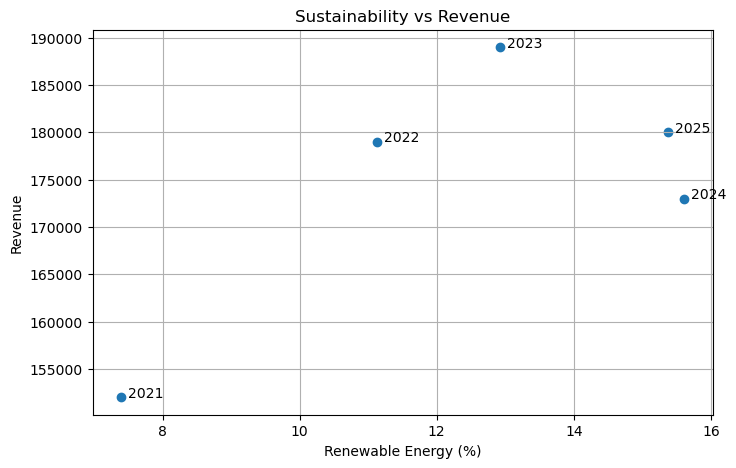

In [90]:
plt.figure(figsize=(8,5))

plt.scatter(final_df["Renewable_%"], final_df["Revenue"])

for i in range(len(final_df)):
    plt.text(
        final_df["Renewable_%"][i] + 0.1,
        final_df["Revenue"][i],
        final_df["Year"][i]
    )

plt.xlabel("Renewable Energy (%)")
plt.ylabel("Revenue")
plt.title("Sustainability vs Revenue")
plt.grid()

plt.show()

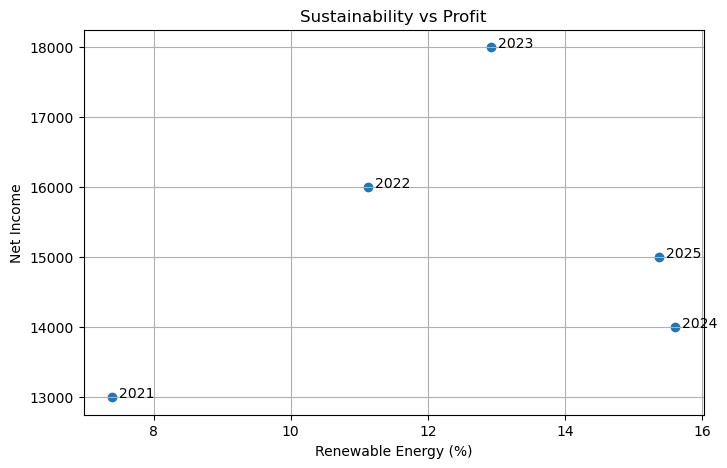

In [91]:
plt.figure(figsize=(8,5))

plt.scatter(final_df["Renewable_%"], final_df["Net_Income"])

for i in range(len(final_df)):
    plt.text(
        final_df["Renewable_%"][i] + 0.1,
        final_df["Net_Income"][i],
        final_df["Year"][i]
    )

plt.xlabel("Renewable Energy (%)")
plt.ylabel("Net Income")
plt.title("Sustainability vs Profit")
plt.grid()

plt.show()

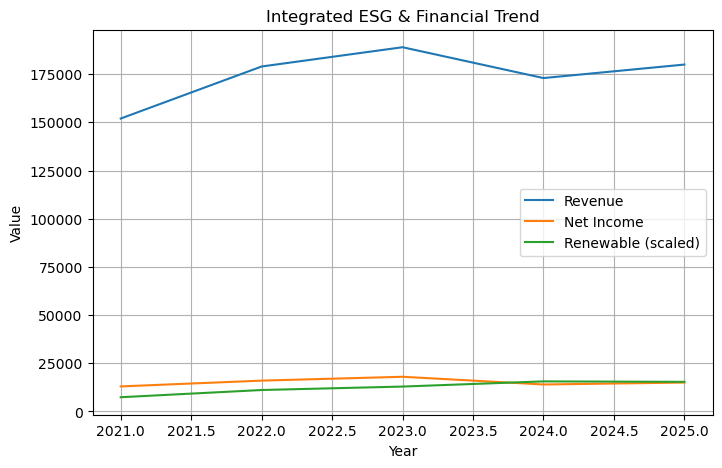

In [92]:
plt.figure(figsize=(8,5))

plt.plot(final_df["Year"], final_df["Revenue"], label="Revenue")
plt.plot(final_df["Year"], final_df["Net_Income"], label="Net Income")
plt.plot(final_df["Year"], final_df["Renewable_%"] * 1000, label="Renewable (scaled)")

plt.title("Integrated ESG & Financial Trend")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid()

plt.show()

In [93]:
comparison = final_df[final_df["Year"].isin([2024, 2025])].reset_index(drop=True)
comparison

,Year,Revenue,Net_Income,Renewable_%
0,2024,173000,14000,15.61
1,2025,180000,15000,15.37


## Conclusioni

L’analisi integrata tra indicatori ESG e performance finanziaria di Stellantis evidenzia una relazione moderatamente positiva tra l’aumento della quota di energia rinnovabile e i ricavi aziendali.

Nel periodo 2021–2025 si osserva un miglioramento continuo degli indicatori ambientali, con un incremento significativo della quota di energia rinnovabile (dal ~7% a oltre il 15%). Parallelamente, i ricavi mostrano un trend complessivamente crescente, suggerendo che la transizione sostenibile non ha compromesso la crescita economica.

Al contrario, il Net Income presenta una relazione meno lineare, con alcune fluttuazioni negli anni più recenti (in particolare tra il 2024 e il 2025). Questo indica che i benefici economici delle strategie ESG non si riflettono immediatamente sulla redditività, probabilmente a causa di investimenti iniziali e costi di transizione.

Il confronto tra 2024 e 2025 evidenzia:

* un aumento dei ricavi
* un miglioramento del Net Income
* una stabilizzazione della quota di energia rinnovabile

Questi elementi suggeriscono una fase di maturazione della strategia ESG, in cui gli investimenti iniziali iniziano a tradursi in risultati economici più stabili.

In sintesi, l’analisi conferma che la sostenibilità rappresenta un driver strategico di medio-lungo periodo, con impatti positivi sui ricavi e un effetto progressivo sulla redditività.


In [94]:
output_path = PROCESSED_DIR / "final_dataset.csv"
final_df.to_csv(output_path, index=False)

print("File salvato in:", output_path)

File salvato in: ..\data_processed\final_dataset.csv
